# FINAL: many-PT period counts

Set **`DATASET`** in cell 2 (`mnist` or `cifar10`). Reads precomputed CSVs from `results_many_seeds/{dataset}/` (output of `scripts/train_many_seeds.py`). Plots go to `local/save/plots/FINAL/{mnist|cifar}/many_pt/`.

MNIST: 2 PDFs. CIFAR: 4 PDFs (mean + box, each with `_inception` / `_resnet` suffix). No training or period extraction in this notebook.


In [5]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
DATASET = "mnist"  # or "cifar10"


In [7]:
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def _find_project_root(start: Path | None = None) -> Path:
	p = (start or Path.cwd()).resolve()
	for cand in [p, *p.parents]:
		if (cand / "pyproject.toml").is_file():
			return cand
	return p

PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
	sys.path.insert(0, str(PROJECT_ROOT))

from analysis.common import _opt_color, _opt_label, _sort_optimizer_ids
from analysis.final.final_analysis_config import (
	dataset_key,
	model_ids_for_dataset,
	require_dataset,
)
from analysis.final.final_experiment_display import (
	ExperimentDisplayLabels,
	normalize_experiment_display_label,
	rename_experiments_for_labels,
	sort_experiment_display_names,
	two_row_cat12_from_sorted,
)
from analysis.final.plot_dataset_context import (
	with_arch_filename,
	with_arch_title,
)
from scripts.train_many_seeds import RUN_SUMMARY_NAME, load_aggregate_tables

require_dataset(DATASET)
MODEL_IDS = model_ids_for_dataset(DATASET)
DATASET_KEY = dataset_key(DATASET)
RESULTS_ROOT = PROJECT_ROOT / "results_many_seeds" / DATASET
PLOT_DIR = Path(f"local/save/plots/FINAL/{DATASET_KEY}/many_pt/")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

LABELS = ExperimentDisplayLabels(
	shuffle_all=r"$\text{Shuffle}_{all}$",
	shuffle_nopre="Control global (✗PT)",
	shuffle_interleaved=r"$\text{Shuffle}_{interleaved}$",
	seq_nopre="Control sequential (✗PT)",
	seq_pre="Control sequential (✔PT)",
	shuffle_seq=r"$\text{Shuffle}_{seq}$",
	no_pretrain=" Control (no pretrain)",
)

sns.set_theme(context="talk", style="whitegrid", font_scale=0.95)
mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["savefig.dpi"] = 200

run_summary, _periods_long = load_aggregate_tables(RESULTS_ROOT)
if run_summary.empty:
	raise FileNotFoundError(
		f"No run summary at {RESULTS_ROOT / RUN_SUMMARY_NAME}. "
		"Run scripts/train_many_seeds.py first."
	)

run_summary = run_summary.copy()
run_summary["experiment_plot"] = run_summary["eid"].map(
	lambda eid: rename_experiments_for_labels(str(eid), LABELS)
)
run_summary = run_summary[run_summary["mid"].isin(MODEL_IDS)].copy()

print(
	f"Loaded {len(run_summary)} rows from {RESULTS_ROOT / RUN_SUMMARY_NAME}; "
	f"plots -> {PLOT_DIR}"
)


Loaded 315 rows from /home/garvalov/thesis/plateau_optimizer/network_analyzer/results_many_seeds/mnist/run_summary.csv; plots -> local/save/plots/FINAL/mnist/many_pt


Mean ± SEM and 95% CI per experiment (pooled over optimizers):
  Control global (✗PT): 100.486 ± 12.968 [75.069, 125.903] (n=35)
  $\text{Shuffle}_{\{0,1\}}$: 4.571 ± 0.552 [3.490, 5.653] (n=35)
  $\text{Shuffle}_{interleaved}$: 15.086 ± 1.956 [11.252, 18.919] (n=35)
  $\text{Shuffle}_{all}$: 24.914 ± 2.685 [19.652, 30.177] (n=35)
  Control sequential (✗PT): 93.343 ± 7.577 [78.492, 108.193] (n=35)
  Control sequential (✔PT): 26.714 ± 3.117 [20.606, 32.823] (n=35)
  $\text{Shuffle}_{seq}$: 43.743 ± 5.018 [33.909, 53.577] (n=35)
  Recover: 118.314 ± 13.890 [91.090, 145.538] (n=35)
  Reinforce: 130.486 ± 14.947 [101.190, 159.781] (n=35)
Mean ± SEM and 95% CI by experiment and optimizer:
  Control global (✗PT)
    Sgd: 178.143 ± 12.343 [153.950, 202.335] (n=7)
    Adagrad: 197.000 ± 12.189 [173.110, 220.890] (n=7)
    Adam: 45.429 ± 3.741 [38.097, 52.760] (n=7)
    Pure Shampoo: 23.714 ± 2.437 [18.938, 28.491] (n=7)
    Grafted Shampoo: 58.143 ± 9.994 [38.555, 77.731] (n=7)
  $\text{Shuffl

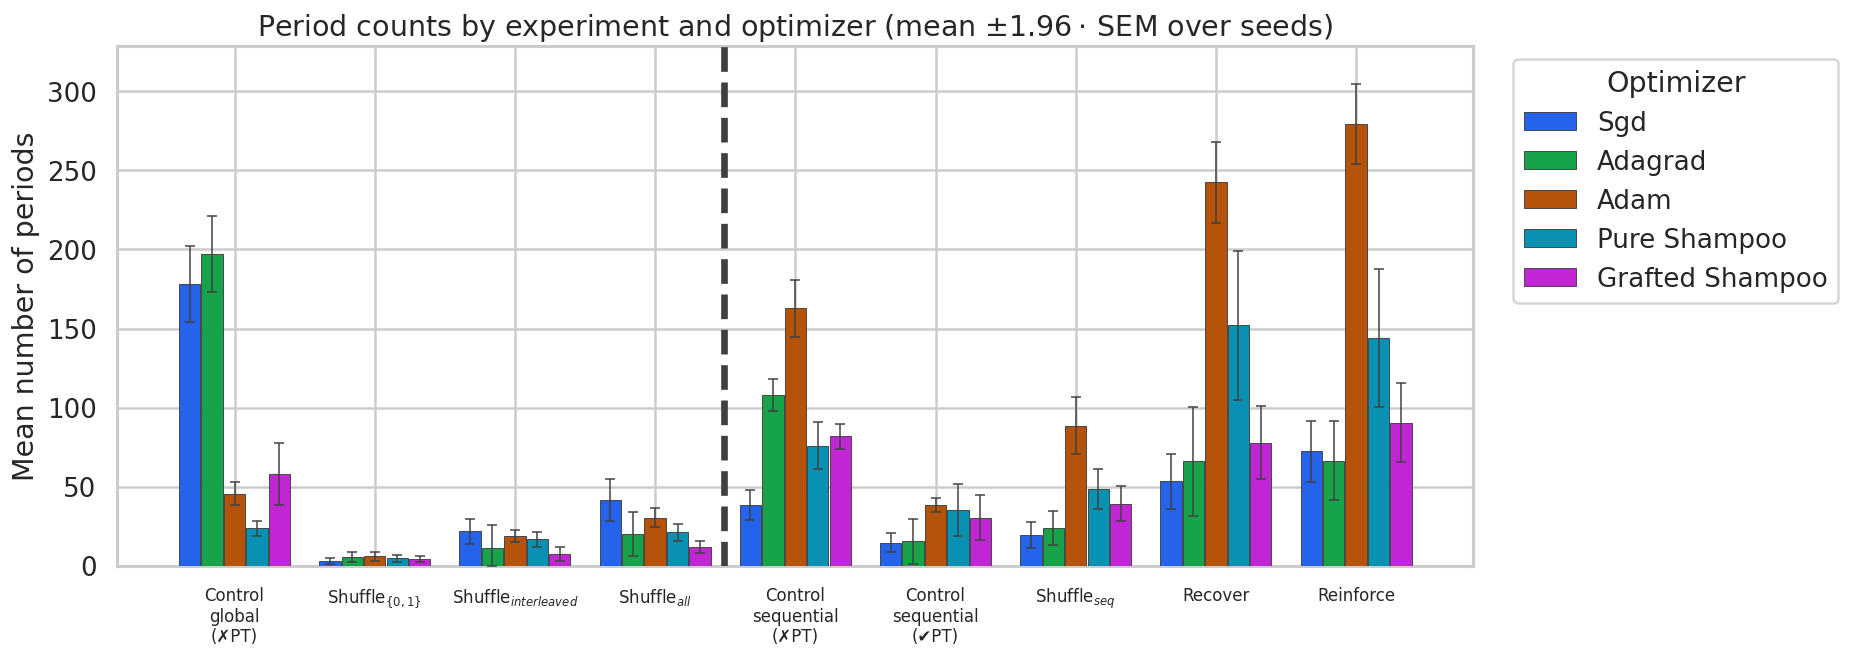

Saved local/save/plots/FINAL/mnist/many_pt/period_counts_mean_sem.pdf


/tmp/ipykernel_396592/3913879046.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_396592/3913879046.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/tmp/ipykernel_396592/3913879046.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_396592/3913879046.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/tmp/ipykernel_396592/3913879046.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.

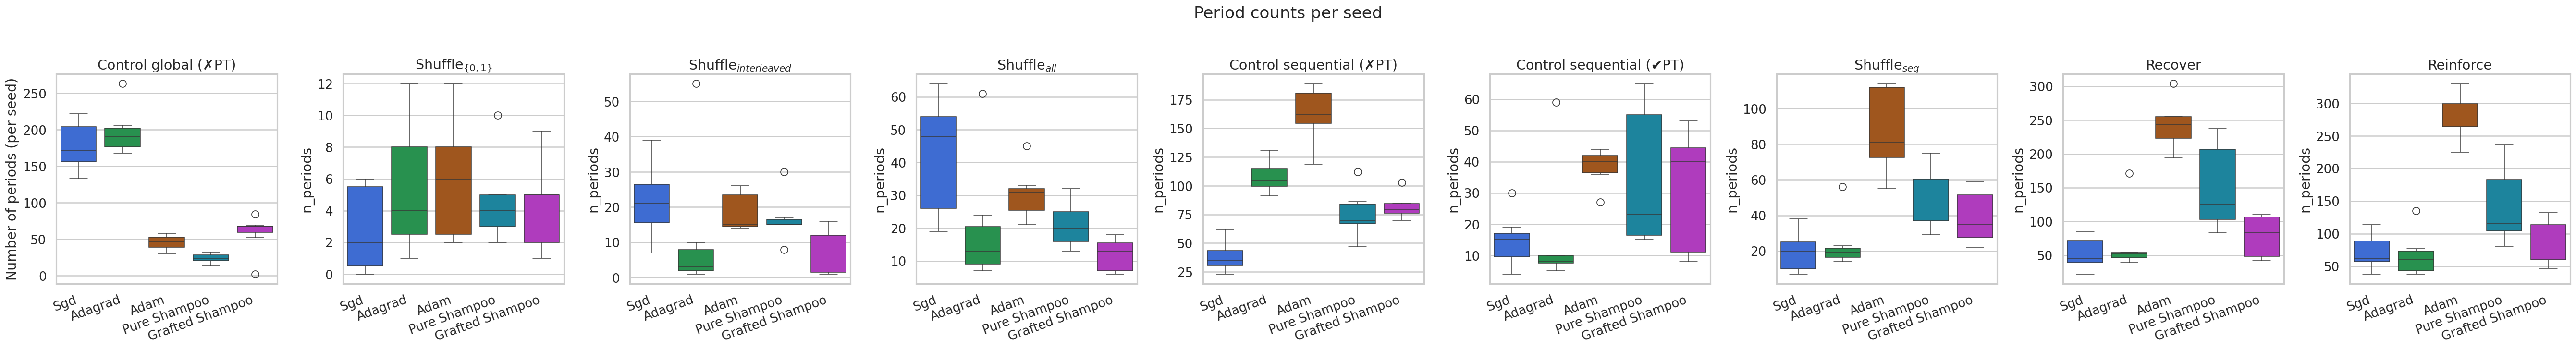

Saved local/save/plots/FINAL/mnist/many_pt/period_counts_per_seed_box.pdf
Done: 2 PDF(s) written under local/save/plots/FINAL/mnist/many_pt


In [10]:
def _sem_across_values(s: pd.Series) -> float:
	v = pd.to_numeric(s, errors="coerce").dropna()
	if len(v) <= 1:
		return 0.0
	return float(v.std(ddof=1) / np.sqrt(len(v)))


def _optimizer_legend_label(oid: str) -> str:
	return " ".join(
		part.lower().capitalize() for part in _opt_label(oid).split("_")
	)


def _xtick_label(exp: str) -> str:
	lab = normalize_experiment_display_label(str(exp), LABELS)
	return "\n".join(lab.split(" "))


def plot_period_counts_for_model(
	dfp: pd.DataFrame,
	*,
	plot_dir: Path,
	filename_suffix: str = "",
	title_suffix: str = "",
) -> tuple[Path, Path] | None:
	if dfp.empty:
		print(f"No rows for model slice{title_suffix or filename_suffix}; skipping.")
		return None

	agg = (
		dfp.groupby(["experiment_plot", "optimizer_id"], as_index=False)
		.agg(
			mean_n=("n_periods", "mean"),
			sem_n=("n_periods", _sem_across_values),
			n_seeds=("n_periods", "count"),
		)
	)
	agg["ci95_half"] = 1.96 * agg["sem_n"]
	agg["ci_lo"] = np.maximum(agg["mean_n"] - agg["ci95_half"], 0.0)
	agg["ci_hi"] = agg["mean_n"] + agg["ci95_half"]

	exp_order = sort_experiment_display_names(agg["experiment_plot"].unique(), LABELS)
	cat1_row, _, _ = two_row_cat12_from_sorted(exp_order, LABELS)
	cat1_divider_idx = len(cat1_row) - 1
	opt_order = _sort_optimizer_ids(agg["optimizer_id"].unique().tolist())

	exp_stats = (
		dfp.groupby("experiment_plot")["n_periods"]
		.agg(mean_n="mean", sem_n=_sem_across_values, n_runs="count")
		.reindex(exp_order)
	)
	exp_stats["ci95_half"] = 1.96 * exp_stats["sem_n"]
	exp_stats["ci_lo"] = np.maximum(exp_stats["mean_n"] - exp_stats["ci95_half"], 0.0)
	exp_stats["ci_hi"] = exp_stats["mean_n"] + exp_stats["ci95_half"]
	print(f"Mean ± SEM and 95% CI per experiment (pooled over optimizers){title_suffix}:")
	for exp, row in exp_stats.iterrows():
		print(
			f"  {exp}: {row['mean_n']:.3f} ± {row['sem_n']:.3f} "
			f"[{row['ci_lo']:.3f}, {row['ci_hi']:.3f}] (n={int(row['n_runs'])})"
		)

	print(f"Mean ± SEM and 95% CI by experiment and optimizer{title_suffix}:")
	for exp in exp_order:
		print(f"  {exp}")
		for oid in opt_order:
			row = agg[
				(agg["experiment_plot"] == exp) & (agg["optimizer_id"] == oid)
			]
			if row.empty:
				continue
			r = row.iloc[0]
			print(
				f"    {_optimizer_legend_label(oid)}: {r['mean_n']:.3f} ± {r['sem_n']:.3f} "
				f"[{r['ci_lo']:.3f}, {r['ci_hi']:.3f}] (n={int(r['n_seeds'])})"
			)

	fig, ax = plt.subplots(figsize=(max(10, len(exp_order) * 1.75), 5.8))
	x = np.arange(len(exp_order))
	width = 0.8 / max(len(opt_order), 1)

	for i, oid in enumerate(opt_order):
		sub = agg[agg["optimizer_id"] == oid].set_index("experiment_plot").reindex(exp_order)
		means = sub["mean_n"].to_numpy(dtype=float)
		ci_lo = sub["ci_lo"].to_numpy(dtype=float)
		ci_hi = sub["ci_hi"].to_numpy(dtype=float)
		yerr_lo = means - ci_lo
		yerr_hi = ci_hi - means
		offset = (i - (len(opt_order) - 1) / 2.0) * width
		if i == len(opt_order) - 1 and cat1_divider_idx >= 0:
			ax.axvline(
				x=cat1_divider_idx + offset + 0.17,
				color="0.25",
				linestyle="--",
				linewidth=4,
			)
		ax.bar(
			x + offset,
			means,
			width=width * 0.95,
			label=_optimizer_legend_label(oid),
			color=_opt_color(oid),
			edgecolor="0.25",
			linewidth=0.55,
			zorder=2,
		)
		ax.errorbar(
			x + offset,
			means,
			yerr=[yerr_lo, yerr_hi],
			fmt="none",
			ecolor="0.25",
			elinewidth=0.9,
			capsize=3,
			capthick=0.9,
			clip_on=False,
			zorder=5,
		)

	for spine in ax.spines.values():
		spine.set_zorder(1)
	ax.set_ylim(bottom=0, top=float(np.nanmax(agg["ci_hi"])) * 1.08 if not agg.empty else 1.0)

	ax.set_xticks(x)
	ax.set_xticklabels([_xtick_label(e) for e in exp_order], fontsize=10)
	ax.set_xlabel("")
	ax.set_ylabel("Mean number of periods")
	ax.set_title(
		with_arch_title(
			"Period counts by experiment and optimizer (mean "
			+ r"$\pm 1.96\cdot\,\text{SEM}$"
			+ " over seeds)",
			title_suffix,
		)
	)
	ax.legend(title="Optimizer", bbox_to_anchor=(1.02, 1), loc="upper left")
	plt.tight_layout()
	out_pdf = plot_dir / with_arch_filename("period_counts_mean_sem.pdf", filename_suffix)
	plt.savefig(out_pdf, bbox_inches="tight")
	plt.show()
	print(f"Saved {out_pdf}")

	fig2, axes = plt.subplots(
		1,
		len(exp_order),
		figsize=(max(8, 5 * len(exp_order)), 6),
		squeeze=False,
	)
	for i, (ax, exp) in enumerate(zip(axes.ravel(), exp_order)):
		sub = dfp[dfp["experiment_plot"] == exp]
		order = _sort_optimizer_ids(sub["optimizer_id"].unique().tolist())
		if len(order) < 2:
			ax.set_visible(False)
			continue
		sns.boxplot(
			data=sub,
			x="optimizer_id",
			y="n_periods",
			order=order,
			palette=[_opt_color(o) for o in order],
			ax=ax,
			linewidth=0.9,
			showfliers=True,
		)
		ax.set_xticklabels(
			[_optimizer_legend_label(o) for o in order],
			rotation=20,
			ha="right",
		)
		ax.set_title(normalize_experiment_display_label(str(exp), LABELS))
		ax.set_xlabel("")
		if i == 0:
			ax.set_ylabel("Number of periods (per seed)")
	fig2.suptitle(with_arch_title("Period counts per seed", title_suffix), y=1.02)
	plt.tight_layout()
	out_box = plot_dir / with_arch_filename("period_counts_per_seed_box.pdf", filename_suffix)
	plt.savefig(out_box, bbox_inches="tight")
	plt.show()
	print(f"Saved {out_box}")
	return out_pdf, out_box


def iter_many_pt_model_contexts(dataset: str, mids: set[str]):
	from analysis.final.plot_dataset_context import CIFAR_MODELID_ORDER, _context_for_mid

	key = dataset_key(dataset)
	if key == "cifar":
		for model_id in CIFAR_MODELID_ORDER:
			if model_id in mids:
				yield _context_for_mid(model_id)
		return
	for model_id in model_ids_for_dataset(dataset):
		if model_id in mids:
			yield _context_for_mid(model_id)


saved: list[Path] = []
present_mids = set(run_summary["mid"].astype(str))
for mid, _arch_slug, filename_suffix, title_suffix in iter_many_pt_model_contexts(
	DATASET, present_mids
):
	slice_df = run_summary[run_summary["mid"] == mid].copy()
	paths = plot_period_counts_for_model(
		slice_df,
		plot_dir=PLOT_DIR,
		filename_suffix=filename_suffix,
		title_suffix=title_suffix,
	)
	if paths is not None:
		saved.extend(paths)

print(f"Done: {len(saved)} PDF(s) written under {PLOT_DIR}")
